### Classe de amostras

In [16]:
class Sample:
	_values: dict
	_name: str

	def __init__(self, name: str, values: dict):
		self._name = name
		self._values = values

	def getMaxValue(self):
		return max(self._values.values())

	def getGreaterPredominance(self):
		samples = []
		max = self.getMaxValue()
		for sample, value in self._values.items():
			if(value == max):
				samples.append(sample)

		return samples
	
	def getValues(self):
		return self._values

	def getName(self):
		return self._name
	

Criei uma classe Sample para encapsular alguns métodos úteis, como é necessário algumas informações por amostra e outras por fungo achei interessante fazer dessa forma.
A classe tem duas propriedades valores (_values um dicionário) e nome (_name uma string) e 3 métodos além do construtor (`__init__`).

* `__init__` - Método construtor, usado para definir parâmetros de criação, parâmetros estes que carregam os valores de _values e _name
* `getMaxValue` - Retorna o valor máximo dentre os fungos da amostra
* `getGreaterPredominance`- Método para pegar os fungos com maior abundância na amostra, utilizo o `getMaxValue` e agrupo as amostras que ocorrem em mesma abundância que o máximo
* `getValues` - Retorna os values da amostra (por convenção)
* `getName` - Retorna o nome da amostra (por convenção)

### Verificar abundância

In [17]:
def checkFungusAbundance(samples: list[Sample]):
	max = -1
	currentSample = 0
	for sample in samples:
		maxValue = sample.getMaxValue()
		if(max < maxValue):
			max = maxValue
			currentSample = sample
	
	print(f"Fungo mais abundante: {''.join(map(str, currentSample.getGreaterPredominance()))}")
	print(f"Solo com maior abundância: {currentSample.getName()}")

Crio um função que recebe uma lista de amostras (classe Sample), utilizo dos métodos definidos na classe para capturar as informações necessárias.
1. Defino as variáveis de controle
2. Percorro com um laço todas as amostras
	1. Capturo os máximo e comparo com o máximo eleito
	2. Caso o máximo da amostra seja maior do que o eleito anteriormente troco os valores nas variáveis de controle
3. Printo os valores, utilizando os métodos da classe

### Definição das variáveis de amostras

In [18]:
soilA = Sample("Solo A",{
	"Aspergillus": 15,
	"Fusarium": 2,
	"Penicillium": 8,
	"Trichoderma": 1,
	"Cladosporium": 7,
})

soilB = Sample("Solo B", {
	"Aspergillus": 3,
	"Fusarium": 10,
	"Penicillium": 6,
	"Trichoderma": 9,
	"Cladosporium": 2,
})

soilC = Sample("Solo C", {
	"Aspergillus": 8,
	"Fusarium": 1,
	"Penicillium": 12,
	"Trichoderma": 4,
	"Cladosporium": 11,
})

### Repostas

In [19]:
soilSamples = [soilA,soilB,soilC]
checkFungusAbundance(soilSamples)

for soil in soilSamples:
	print(f"Mais abundantes na amostra {soil.getName()}: {''.join(map(str,soil.getGreaterPredominance()))}")

Fungo mais abundante: Aspergillus
Solo com maior abundância: Solo A
Mais abundantes na amostra Solo A: Aspergillus
Mais abundantes na amostra Solo B: Fusarium
Mais abundantes na amostra Solo C: Penicillium


Aqui, agrupei os 3 solos em uma lista para poder utilizar na função `checkFungusAbundance` e percorre-los para capturar os fungos com maior amostragem (utilizando o método `getGreaterPredominance`) 

### Gráficos

{'Solo A': [15, 2, 8, 1, 7], 'Solo B': [3, 10, 6, 9, 2], 'Solo C': [8, 1, 12, 4, 11]}


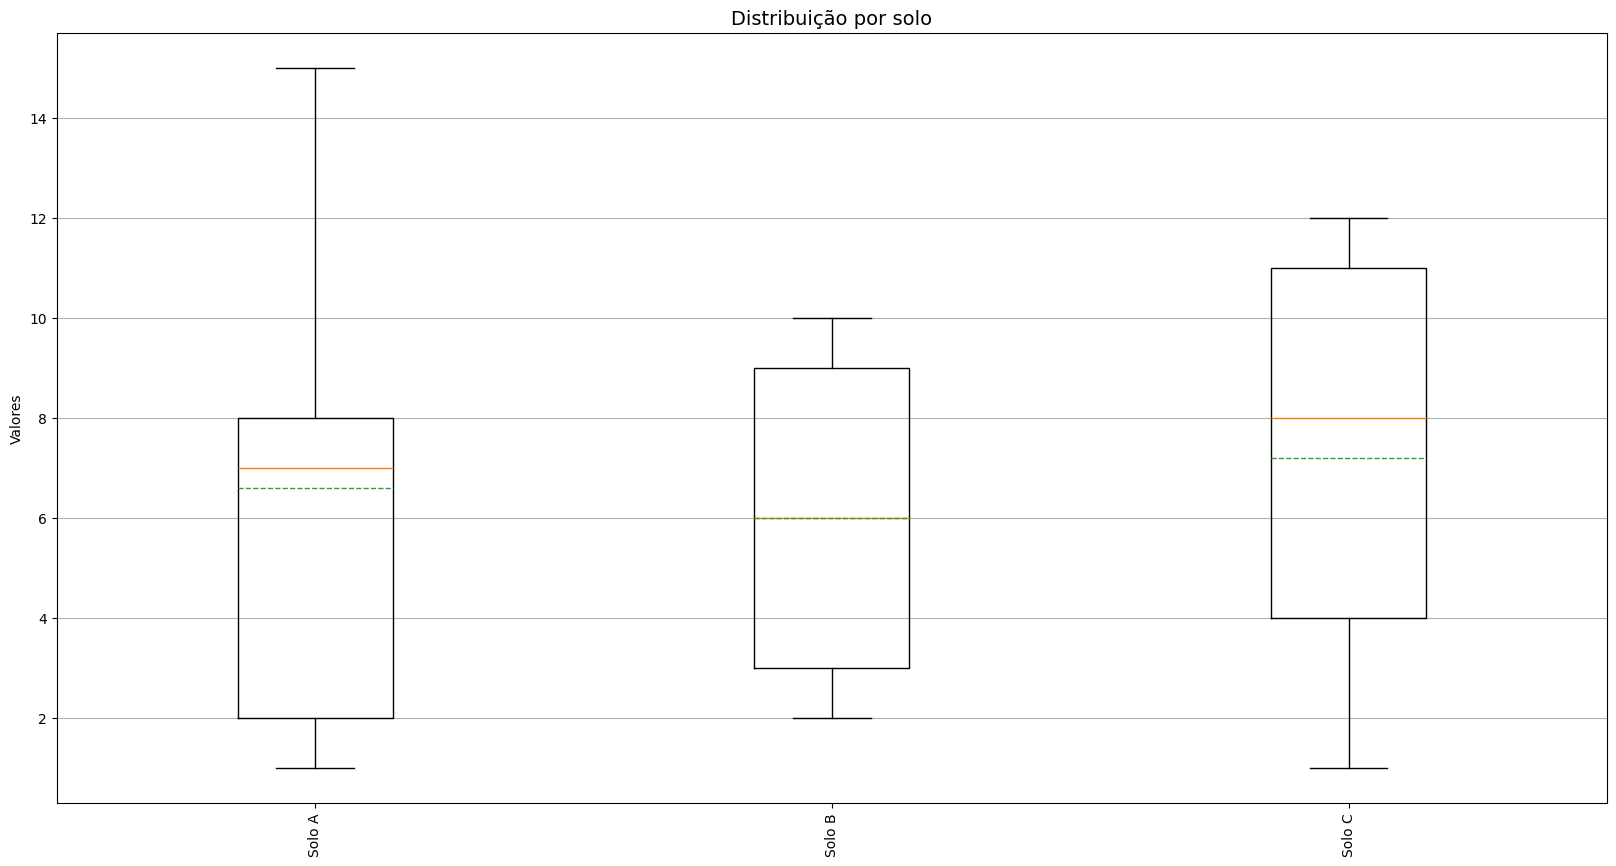

In [26]:
import matplotlib.pyplot as plot

soilValues = {}
for soil in soilSamples:	
	soilName = soil.getName()
	soilValues[soilName] = []
	for val in soil.getValues().values():
		soilValues[soilName].append(val)

print(soilValues)


soilLables = list(soilValues.keys())
soilValues = list(soilValues.values())

plot.figure(figsize=(20, 10))

plot.boxplot(
	soilValues,
	tick_labels=soilLables,
	showmeans=True,
	meanline=True
)
plot.title("Distribuição por solo", fontsize=14)
plot.ylabel("Valores")
plot.xticks(rotation=90)
plot.grid(axis='y', alpha=1)
plot.show()
